In [1]:
import torch

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [2]:

from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

model = build_sam3_image_model()
processor = Sam3Processor(model)

E:\Uni\Bachelorarbeit\sam3\sam3\model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:

image_path = "dataset/mvtec_anomaly_detection/hazelnut/test/print/005.png"
image = Image.open(image_path)
inference_state = processor.set_image(image)

tensor([0.6719, 0.5312], device='cuda:0', dtype=torch.bfloat16)
torch.Size([2, 1, 1024, 1024])
found 2 object(s)


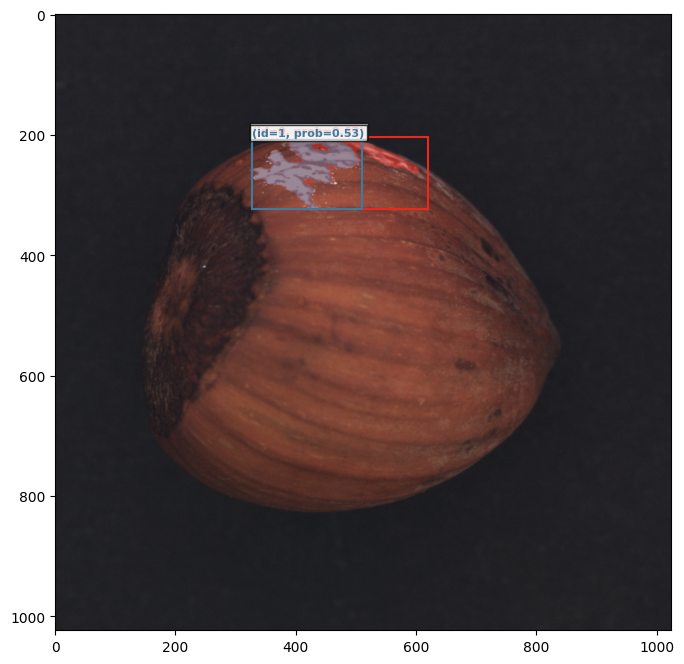

In [ ]:
processor.reset_all_prompts(inference_state)

inference_state = processor.set_confidence_threshold(state=inference_state, threshold=0.5)
inference_state = processor.set_text_prompt(state=inference_state, prompt="white print")


masks, boxes, scores = inference_state["masks"].to(torch.float), inference_state["boxes"], inference_state["scores"]
print(scores)
print(inference_state["masks_logits"].shape)
img0 = Image.open(image_path)
plot_results(img0, inference_state)

In [5]:
ground_truth = "dataset/mvtec_anomaly_detection/hazelnut/ground_truth/print/005_mask.png"

In [ ]:
from anomalib.metrics import AUROC, AUPRO, PRO
from anomalib.data.dataclasses.torch import ImageBatch, ImageItem
from torchvision import transforms
image_auroc = AUROC(fields=["pred_score", "gt_label"], prefix="image")
pixel_auroc = AUROC(fields=["anomaly_map", "gt_mask"], prefix="pixel")
pixel_aupro = AUPRO(fpr_limit=0.3,fields=["anomaly_map", "gt_mask"])
gt = Image.open(ground_truth)
transform = transforms.ToTensor()
#pred_label = torch.tensor([0])
#print(inference_state["masks_logits"])

pred_label= torch.tensor(0, dtype=int).to(device="cuda")

if(masks.size(dim=0) != 0):
    single_map = torch.max(inference_state["masks_logits"], dim=0).values
    single_mask = torch.max(masks, dim=0).values
    pred_label = torch.tensor(1, dtype=int).to(device="cuda")
else:
    single_map = torch.zeros(1,inference_state["original_height"], inference_state["original_width"]).to(device="cuda")
    single_mask = torch.zeros(1,inference_state["original_height"], inference_state["original_width"], dtype=int).to(device="cuda")


image_path_list = []
image_path_list.append(image_path)

mask_path_list = []
mask_path_list.append(ground_truth)

item = ImageItem(
    image=transform(img0).to(device="cuda"),
    gt_label=torch.tensor(1, dtype=int).to(device="cuda"),
    image_path=image_path,
    pred_label=pred_label,
    pred_mask=single_mask,
    pred_score=torch.max(scores, dim=0).values,
    gt_mask=transform(gt).to(device="cuda"),
    mask_path=ground_truth,
    anomaly_map = single_map
)

print(item.pred_mask.type())

"""
item = ImageBatch(
    image=transform(img0).to(device="cuda"),
    gt_label=gt_label,
    #image_path=image_path_list,
    pred_label=pred_label,
    pred_mask=single_mask,
    pred_score=scores,
    gt_mask=transform(gt).to(device="cuda"),
    #mask_path=mask_path_list,
    anomaly_map = single_map
)"""


#auroc.update(item)
#for batch in item:
image_auroc.update(item)
pixel_auroc.update(item)
pixel_aupro.update(item)

print("image AUROC: ")
print(image_auroc.compute())
print("pixel AUROC: ")
print(pixel_auroc.compute())
print("pixel AUPRO")
print(pixel_aupro.perform_cca())

torch.cuda.BoolTensor
image AUROC: 
tensor(0., device='cuda:0')
pixel AUROC: 
tensor(0., device='cuda:0')
pixel AUPRO


ValueError: Input image shape must be (*,1,H,W). Got: torch.Size([1024, 1, 1024])